# Tutorial 3: Filter Traces by Direct Thresholds

## Objective
Apply direct filtering criteria to remove obvious artifacts while preserving data quality.

## Scientific Context
Raw traces often contain:
- **Incomplete traces**: Too few barcodes detected (outliers in lower tail of distribution)
- **Out-of-focus regions**: Z-coordinates outside optimal focal plane
- **Duplicate barcodes**: Optical/detection artifacts (barcode repeated in same trace)

Direct threshold filtering removes these before downstream analysis (matrix visualization, colocalization).

## Scripts Used
- `trace_filter` - Apply spatial and barcode filters
- `trace_analyzer` - Assess impact of filtering

## Step 1: Setup

In [12]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Set up data paths
data_path = "/home/xdevos/Repositories/pyHi-M/traceratops/data/RUT"
merged_path = f"{data_path}/merged_output/dest"
filter_path = f"{data_path}/filter_output"

os.makedirs(filter_path, exist_ok=True)

# Input file from Tutorial 2
input_trace = f"{merged_path}/merged_traces.ecsv"

print(f"Input: {input_trace}")
!ls -lh {input_trace}

Input: /home/xdevos/Repositories/pyHi-M/traceratops/data/RUT/merged_output/dest/merged_traces.ecsv
-rw-r--r-- 1 xdevos users 18M 19 mars  09:46 /home/xdevos/Repositories/pyHi-M/traceratops/data/RUT/merged_output/dest/merged_traces.ecsv


## Step 2: Apply Conservative Filtering

From QC analysis (Tutorial 2), the Z-plane distribution shows:
- Mean Z ≈ 6.7 μm, with most barcodes in range [2.6, 11.2] μm
- Filtering strategy: Keep Z in range [3.0, 11.0] μm (removes ~5% extreme outliers from each side)
- Remove barcodes with < 10 total (incomplete traces)
- Clean duplicate spots and repeated barcodes

Using conservative thresholds preserves data quality while removing obvious artifacts.

In [ ]:
# Apply conservative filtering in a single pass
# - Keep traces with >= 10 barcodes (removes bottom outliers only)
# - Keep Z in range [3.0, 11.0] micrometers (keeps ~90% of data, removes extreme outliers)
!cd {filter_path} && cp {input_trace} . && trace_filter --input merged_traces.ecsv --z_min 3.0 --z_max 11.0 --n_barcodes 10 --output filtered

## Step 3: Run QC Analysis on Filtered Data

In [15]:
# Analyze the filtered dataset
!trace_analyzer --input {filter_path}/merged_traces_filtered.ecsv -F {filter_path}


1 trace files to process= /home/xdevos/Repositories/pyHi-M/traceratops/data/RUT/filter_output/merged_traces_filtered.ecsv
$ Importing table from pyHiM format
Successfully loaded trace table: /home/xdevos/Repositories/pyHi-M/traceratops/data/RUT/filter_output/merged_traces_filtered.ecsv
> Analyzing traces for /home/xdevos/Repositories/pyHi-M/traceratops/data/RUT/filter_output/merged_traces_filtered.ecsv
$ Number of spots in trace file: 8687
$ Calculating overall barcode detection across 722 traces...
$ Exporting barcode detection plot to: /home/xdevos/Repositories/pyHi-M/traceratops/data/RUT/filter_output/merged_traces_filtered_barcode_detection.png
$ Saved neighbor distances plot: /home/xdevos/Repositories/pyHi-M/traceratops/data/RUT/filter_output/merged_traces_filtered_first_neighbor_distances.png
$ Mean distances between neighboring barcodes: X=-0.002, Y=0.003, Z=0.004
$ Calculating barcode stats...
100%|███████████████████████████████████████| 722/722 [00:00<00:00, 7205.56it/s]
$ E

## Step 4: Visualize Filtered Barcode Detection

▶ Barcode Detection After Filtering:


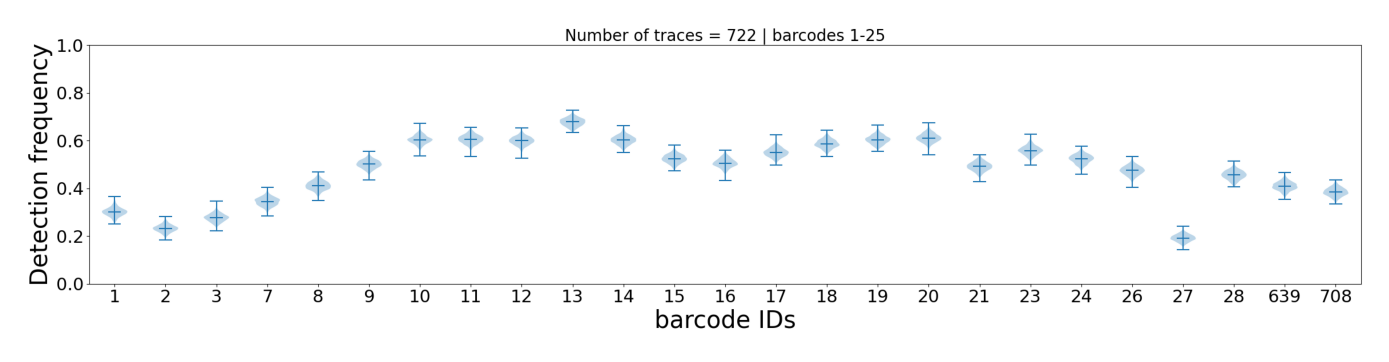

In [16]:
plot_file = f"{filter_path}/merged_traces_filtered_barcode_detection.png"
if os.path.exists(plot_file):
    print("▶ Barcode Detection After Filtering:")
    img = mpimg.imread(plot_file)
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.imshow(img)
    ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print(f"✗ Plot not found at {plot_file}")

## Step 5: Visualize Filtered Trace Statistics

▶ Trace Statistics After Filtering:


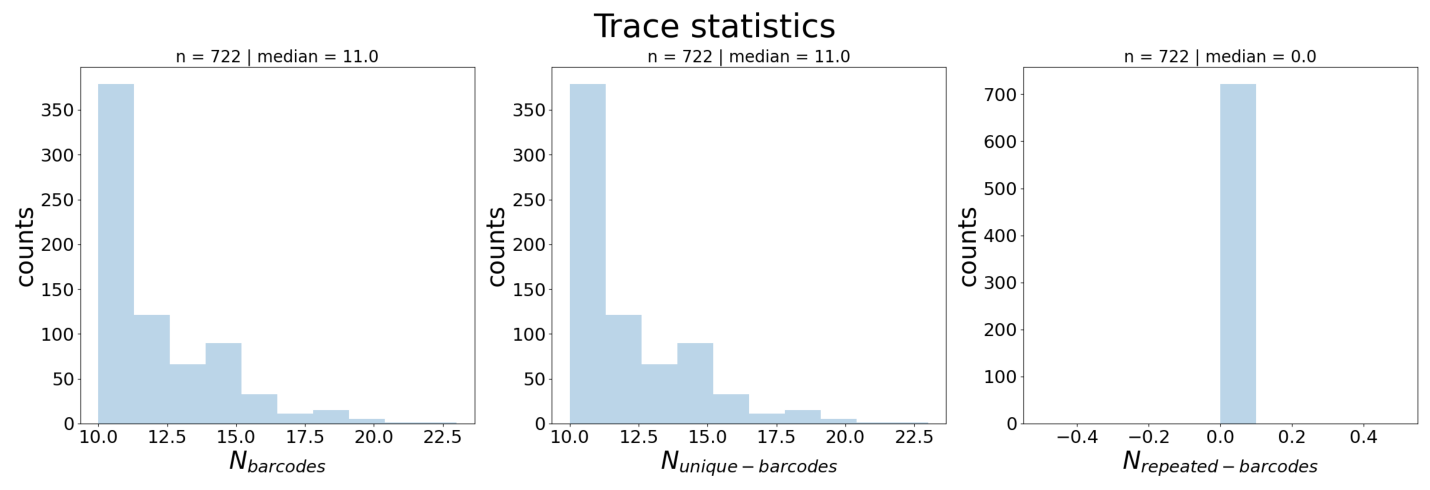

In [17]:
plot_file = f"{filter_path}/merged_traces_filtered_trace_statistics.png"
if os.path.exists(plot_file):
    print("▶ Trace Statistics After Filtering:")
    img = mpimg.imread(plot_file)
    fig, ax = plt.subplots(figsize=(16, 5))
    ax.imshow(img)
    ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print(f"✗ Plot not found at {plot_file}")

## Filtering Options Reference

### Available Filters

| Option | Purpose | Example |
|--------|---------|----------|
| `--n_barcodes N` | Keep traces with ≥N barcodes | `--n_barcodes 10` |
| `--z_min X --z_max Y` | Keep Z coordinates in [X, Y] | `--z_min 3.0 --z_max 6.0` |
| `--y_min X --y_max Y` | Keep Y coordinates in [X, Y] | `--y_min 100 --y_max 400` |
| `--x_min X --x_max Y` | Keep X coordinates in [X, Y] | `--x_min 100 --x_max 400` |
| `--remove_barcode B1,B2` | Remove specific barcode IDs | `--remove_barcode 1,2` |
| `--keep_label LABEL` | Keep only traces with label | `--keep_label region1` |
| `--remove_label LABEL` | Remove traces with label | `--remove_label region1` |
| `--clean_spots` | Remove duplicate UID + repeated barcodes | (flag) |
| `--localization_file F --intensity_min N` | Filter by localization intensity | `--intensity_min 1000` |
| `--output TAG` | Output file tag | `--output filtered` |
| `--pipe` | Read file list from stdin | (flag) |

### Filtering Order (in trace_filter)

trace_filter applies filters in sequence:
1. **Coordinate filtering** (x, y, z bounds)
2. **Intensity filtering** (if --localization_file provided)
3. **Duplicate cleaning** (if --clean_spots)
4. **Label filtering** (--keep_label or --remove_label)
5. **Barcode removal** (--remove_barcode)
6. **Barcode count filtering** (--n_barcodes) ← **APPLIED LAST**

**Important:** The `--n_barcodes` filter is applied last because earlier filters reduce trace length. This ensures minimum quality thresholds are enforced after other modifications.

## Conservative Threshold Guidelines

To avoid over-filtering and losing data quality:

### N_barcodes Threshold
- **Never** remove more than ~10-20% of traces
- If median N_barcodes = 30, set `--n_barcodes 10-15`
- Lower threshold = fewer traces lost, but keeps some incomplete data
- High threshold = cleaner data, but risk losing valid traces
- **Recommendation**: Set ~1/3 of median value

### Z-plane Range
- From QC ΔZ histogram and statistics, identify the focal range
- **RUT dataset example**: Z range is [0.6, 14.9] μm with mean 6.7 μm
- Use **5th-95th percentile** (captures ~90% of data): 2.6-11.2 μm
- Or use **mean ± 2σ** (standard statistical approach): 1.3-12.2 μm
- Conservative choice: 3.0-11.0 μm (removes extreme outliers, keeps ~90%)
- **Never use very narrow ranges** (3-6 μm) unless specifically justified

### Barcode Removal
- Only remove barcodes if they have **<20% detection efficiency** (very low in violin plot)
- Removing 1-2 problematic barcodes is OK
- Removing many barcodes may indicate a data quality issue

### Cleaning Duplicates
- `--clean_spots` is always safe to use
- Removes obvious artifacts without aggressive thresholding
- Recommended for all filtering operations

## Advanced: Adjusting Thresholds

If you need different filtering parameters:

In [ ]:
# Example: More aggressive filtering (remove more data)
# Uncomment and modify as needed

# !cd {filter_path} && trace_filter --input merged_traces.ecsv \
#   --z_min 4.0 --z_max 10.0 \
#   --clean_spots \
#   --remove_barcode 1,2 \
#   --n_barcodes 15 \
#   --output filtered_strict

## Batch Processing Multiple Files

To apply the same filters to many trace files:

In [ ]:
# Example: Process multiple files (not executed)
# ls *.ecsv | trace_filter --pipe --z_min 3.0 --z_max 11.0 --clean_spots --n_barcodes 10 --output filtered

print("Batch processing syntax:")
print("""ls *.ecsv | trace_filter \\
  --pipe \\
  --z_min 3.0 --z_max 11.0 \\
  --clean_spots \\
  --n_barcodes 10 \\
  --output filtered""")

## Summary

This tutorial demonstrated:

1. ✓ Conservative filtering with reasonable thresholds
2. ✓ Single-pass filtering approach (avoids filename issues)
3. ✓ Combining multiple filters simultaneously
4. ✓ Comparing QC metrics before/after filtering

**Key Concepts:**
- Use conservative thresholds to preserve data quality
- Single-pass filtering is simpler and avoids cascading issues
- Always check QC plots to verify filtering didn't remove too much
- `--clean_spots` is safe and recommended for all filtering
- Barcode count filter applied last ensures minimum quality

**Output:** High-quality filtered trace file (`merged_traces_filtered.ecsv`) ready for downstream analysis

**Next Tutorial:** Handle advanced duplicate detection modes (tutorial_04_filter_duplicates.ipynb)